In [3]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import datetime
from astropy.time import Time

data = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_flux_YVA.npy"
)

jdb = pd.read_csv("/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_summary.csv")["jdb"].values
wavegrid = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_material.p",
    allow_pickle=True,
)["wave"].to_numpy()

In [4]:
with h5py.File(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/spec_cube_tot_filtered_normalized_float32.h5",
    "r",
) as f:
    soap_n_spectra, soap_n_pixels = f["spec_cube"].shape

datachallenge_n_spectra, datachallenge_n_pixels = data.shape

In [9]:
print(soap_n_pixels)
print(datachallenge_n_pixels)

547420
293401


In [5]:
import numpy as np
import datetime
from astropy.time import Time
import h5py

# ============= 1) Temps & matching sans indices corrompus =============
# jdb = t_harps  # (1275,) en "JD - 2400000"
start_date = datetime.datetime(2015, 1, 1)
dates = [start_date + datetime.timedelta(days=i) for i in range(3297)]
t_soap = Time(dates, format="datetime").jd - 2400000.0

bad_idx = np.array([246, 249, 1196, 1453, 2176], dtype=int)
n_original = t_soap.size
valid_idx = np.setdiff1d(np.arange(n_original), bad_idx)
t_valid = t_soap[valid_idx]

# nearest neighbor (sans boucle Python lourde)
pos = np.searchsorted(t_valid, jdb)
pos = np.clip(pos, 1, t_valid.size - 1)
left = pos - 1
right = pos
choose_right = (t_valid[right] - jdb) < (jdb - t_valid[left])
j_valid = np.where(choose_right, right, left)
idx_nearest_old = valid_idx[j_valid]  # indices sur le cube ORIGINAL (3297)

# recalage vers le HDF5 filtré (3292) : new = old - nb_corrompus < old
bad_sorted = np.sort(bad_idx)
shift = np.searchsorted(bad_sorted, idx_nearest_old, side="left")
idx_nearest_new = idx_nearest_old - shift  # indices pour le fichier FILTRÉ (3292)

# (optionnel) contrôle
delta_t = jdb - t_soap[idx_nearest_old]
print("Δt moyen (j):", np.mean(np.abs(delta_t)))
print("Δt max   (j):", np.max(np.abs(delta_t)))
assert np.all(idx_nearest_new >= 0)

# ============= 2) Streaming HDF5: lecture 1-par-1, écriture directe =============
in_path = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/spec_cube_tot_filtered_normalized_float32.h5"
out_path = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/soap_equiv_for_harps.h5"

with h5py.File(in_path, "r") as fin:
    ds_spec = fin["spec_cube"]  # (3292, n_pix), float32
    n_pix = ds_spec.shape[1]
    dtype = ds_spec.dtype

    # crée un fichier de sortie pour ne pas garder en RAM
    with h5py.File(out_path, "w") as fout:
        ds_out = fout.create_dataset(
            "spec_sel",
            shape=(idx_nearest_new.size, n_pix),
            dtype=dtype,
            chunks=(1, n_pix),
            compression="gzip",
        )

        # astuce: ne pas relire 10x le même index -> map des positions de sortie par index source
        # ça évite la RAM: on lit 1 ligne, on la recopie à tous ses emplacements
        positions = {}
        for out_pos, src_idx in enumerate(idx_nearest_new):
            positions.setdefault(int(src_idx), []).append(out_pos)

        for src_idx, outs in positions.items():
            row = ds_spec[src_idx, :]  # lit 1 ligne -> ~O(n_pix) en RAM
            for out_pos in outs:
                ds_out[out_pos, :] = row  # écrit directement sur disque

print("OK → écrit:", out_path, "dataset: /spec_sel")


Δt moyen (j): 0.04530586644156845
Δt max   (j): 0.9831124773190822
OK → écrit: /home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/soap_equiv_for_harps.h5 dataset: /spec_sel


In [6]:
# temps SOAP "équivalents" (même ordre que HARPS), en BJD-2400000.0 comme jdb
t_soap_equiv = t_soap[idx_nearest_old]  # == t_valid[j_valid]

# sauvegarde en .npy
np.save(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/soap_gpu_paper/time_values_soap_equiv_for_harps.npy",
    t_soap_equiv,
)

# (optionnel) pour tracer/contrôler
print(
    t_soap_equiv.shape,
    t_soap_equiv[:5],
    "Δt max (j) =",
    np.max(np.abs(jdb - t_soap_equiv)),
)


(1275,) [57220.5 57223.5 57233.5 57234.5 57235.5] Δt max (j) = 0.9831124773190822


In [6]:
from src.ccf import get_full_ccf_analysis

full_ccf_analysis, raw_ccfs = get_full_ccf_analysis(
    spectra=data,
    wavegrid=wavegrid,
    v_grid=np.arange(-20000, 20000, 250),
    window_size_velocity=820,
    mask_type="G2",
    verbose=True,
    batch_size=100,
    return_raw_ccfs="True",
)

Construction des masques CCF gaussiens (sparse)...
Batch 1/13 traité (100/1275 spectres)
Batch 2/13 traité (200/1275 spectres)
Batch 3/13 traité (300/1275 spectres)
Batch 4/13 traité (400/1275 spectres)
Batch 5/13 traité (500/1275 spectres)
Batch 6/13 traité (600/1275 spectres)
Batch 7/13 traité (700/1275 spectres)
Batch 8/13 traité (800/1275 spectres)
Batch 9/13 traité (900/1275 spectres)
Batch 10/13 traité (1000/1275 spectres)
Batch 11/13 traité (1100/1275 spectres)
Batch 12/13 traité (1200/1275 spectres)
Batch 13/13 traité (1275/1275 spectres)


In [79]:
analyse_summary = pd.read_csv(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_summary.csv"
)
print(analyse_summary.columns)

analyse_material = np.load("/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_material.p", allow_pickle=True)

print(analyse_material.columns)


ccf_analysis = np.load(
        "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_CCF_YVA.p",
        allow_pickle=True,
    )
print(ccf_analysis.keys())

Index(['Unnamed: 0', 'jdb', 'snr_computed', 'berv', 'CaIIH', 'CaIIH_std',
       'CaIIK', 'CaIIK_std', 'CaII_cleaned', 'CaII_cleaned_std', 'Ha',
       'Ha_std', 'Hb', 'Hb_std', 'NaD', 'NaD_std', 'CaI', 'CaI_std'],
      dtype='object')
Index(['wave', 'correction_factor', 'reference_spectrum', 'color_template',
       'blaze_correction', 'rejected', 'mask_brute', 'master_snr_curve',
       'ratio_factor_snr', 'pixels_rnr', 'orders_rnr', 'merged',
       'activity_proxies', 'contam', 'borders_pxl', 'stitching',
       'stitching_delta', 'stitching_pxl', 'ghost_a', 'ghost_b', 'thar',
       'reference_spectrum_backup', 'stellar_template', 'ghost2', 'detector',
       'kitcat_vec', 'sp_model'],
      dtype='object')
dict_keys(['ccf_vrad', 'ccf_flux', 'ccf_flux_std', 'table', 'creation_date'])


ValueError: x and y must have same first dimension, but have shapes (1275,) and (69,)

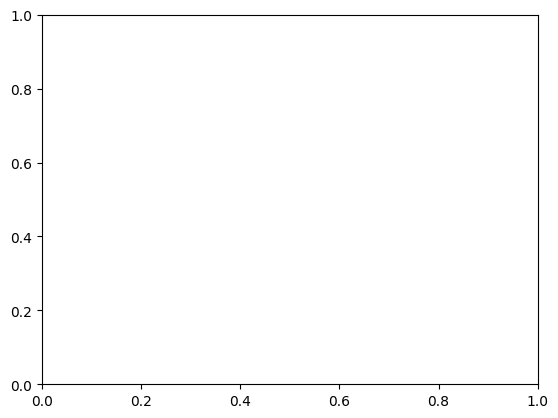

In [77]:
plt.plot(jdb, ccf_vrad, label="CCF Velocity")

/tmp/ipykernel_78548/3896376894.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yv0 = pd.read_csv(f"{file_path}YV0.rdb", delim_whitespace=True, comment="#")
/tmp/ipykernel_78548/3896376894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")


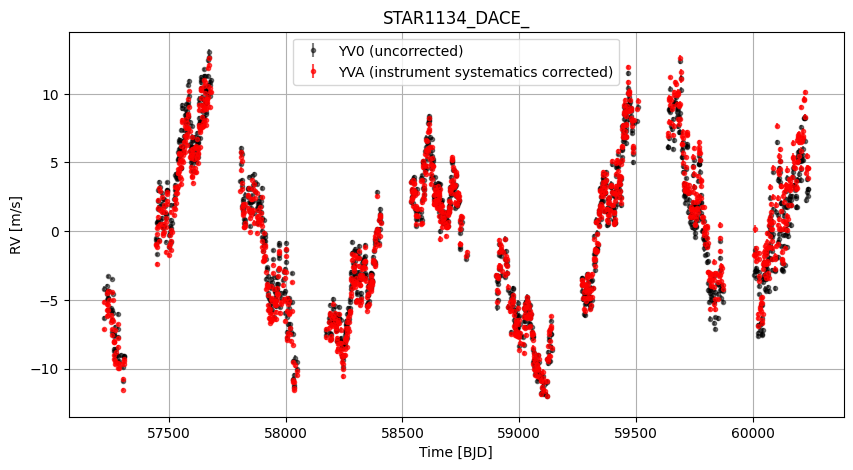

/tmp/ipykernel_78548/3896376894.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yv0 = pd.read_csv(f"{file_path}YV0.rdb", delim_whitespace=True, comment="#")
/tmp/ipykernel_78548/3896376894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")


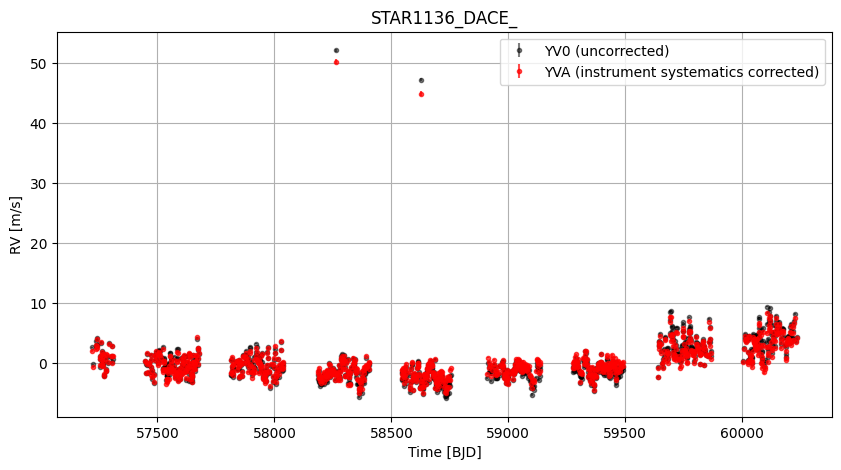

/tmp/ipykernel_78548/3896376894.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yv0 = pd.read_csv(f"{file_path}YV0.rdb", delim_whitespace=True, comment="#")
/tmp/ipykernel_78548/3896376894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")


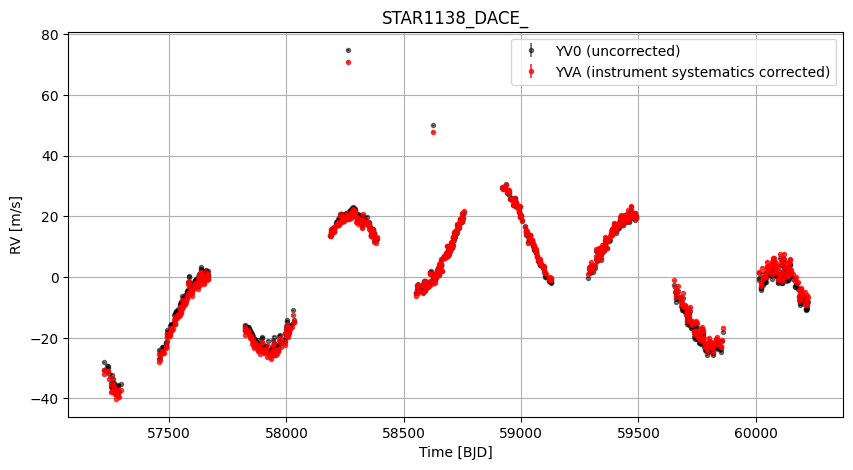

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

for file_path in [
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/STAR1134_DACE_",
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57001_E61001_planet-FallChallenge1/STAR1136_DACE_",
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57002_E61002_planet-FallChallenge2/STAR1138_DACE_",
]:
    # --- Charger YV0 et YVA ---
    df_yv0 = pd.read_csv(f"{file_path}YV0.rdb", delim_whitespace=True, comment="#")
    df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")

    df_yv0 = df_yv0.iloc[1:]  # enlever la premiere ligne
    df_yva = df_yva.iloc[1:]  # enlever la premiere ligne

    df_yv0 = df_yv0.iloc[:, :-1]  # enlever la derniere colonne
    df_yva = df_yva.iloc[:, :-1]  # enlever la derniere colonne

    df_yv0 = df_yv0.astype({"vrad": "float32", "svrad": "float32", "jdb": "float32"})
    df_yva = df_yva.astype({"vrad": "float32", "svrad": "float32", "jdb": "float32"})

    # --- Convertir en m/s et centrer ---
    rv0 = (df_yv0["vrad"] - df_yv0["vrad"].mean()) * 1000
    rv0_err = df_yv0["svrad"] * 1000
    time0 = df_yv0["jdb"]

    rvA = (df_yva["vrad"] - df_yva["vrad"].mean()) * 1000
    rvA_err = df_yva["svrad"] * 1000
    timeA = df_yva["jdb"]

    # --- Tracer ---
    plt.figure(figsize=(10, 5))
    plt.errorbar(
        time0,
        rv0,
        yerr=rv0_err,
        fmt="o",
        ms=3,
        color="black",
        alpha=0.5,
        label="YV0 (uncorrected)",
    )
    plt.errorbar(
        timeA,
        rvA,
        yerr=rvA_err,
        fmt="o",
        ms=3,
        color="red",
        alpha=0.7,
        label="YVA (instrument systematics corrected)",
    )

    plt.xlabel("Time [BJD]")
    plt.ylabel("RV [m/s]")
    plt.title(file_path.strip().split("/")[-1])
    plt.grid()
    plt.legend()
    plt.show()
